# Inference Demo all models
Download the model from HuggingFace, load a validation image, and run inference.

In [ ]:
from huggingface_hub import hf_hub_download
from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

model_path = hf_hub_download(
    repo_id="ErlendTregde/YOLOv9-Norgesgruppen",
    filename="best.pt",
)
print(f"Model downloaded to: {model_path}")

In [ ]:
model = YOLO(model_path)
print(f"Model loaded — {len(model.names)} classes")

Model loaded — 356 classes


In [ ]:
val_images = sorted(Path("../dataset/val/images").glob("*"))
img_path = val_images[0]
print(f"Running inference on: {img_path.name}")

results = model(str(img_path))[0]

Running inference on: img_00005.jpg

image 1/1 /home/coder/IKT452-Computer-Vision-Project/src/../dataset/val/images/img_00005.jpg: 608x800 1 class_1, 3 class_32s, 2 class_45s, 3 class_46s, 6 class_56s, 4 class_63s, 1 class_87, 2 class_89s, 10 class_100s, 1 class_103, 1 class_106, 1 class_111, 3 class_137s, 1 class_141, 1 class_142, 2 class_151s, 1 class_160, 7 class_171s, 1 class_173, 3 class_178s, 2 class_184s, 1 class_187, 3 class_189s, 1 class_200, 1 class_205, 1 class_215, 1 class_222, 1 class_223, 1 class_225, 2 class_259s, 2 class_266s, 4 class_272s, 4 class_282s, 1 class_287, 2 class_297s, 2 class_298s, 4 class_304s, 1 class_309, 1 class_314, 2 class_320s, 1 class_324, 3 class_325s, 1 class_334, 1 class_339, 4 class_340s, 2 class_341s, 1 class_344, 1 class_347, 3 class_355s, 26.6ms
Speed: 2.6ms preprocess, 26.6ms inference, 1.8ms postprocess per image at shape (1, 3, 608, 800)


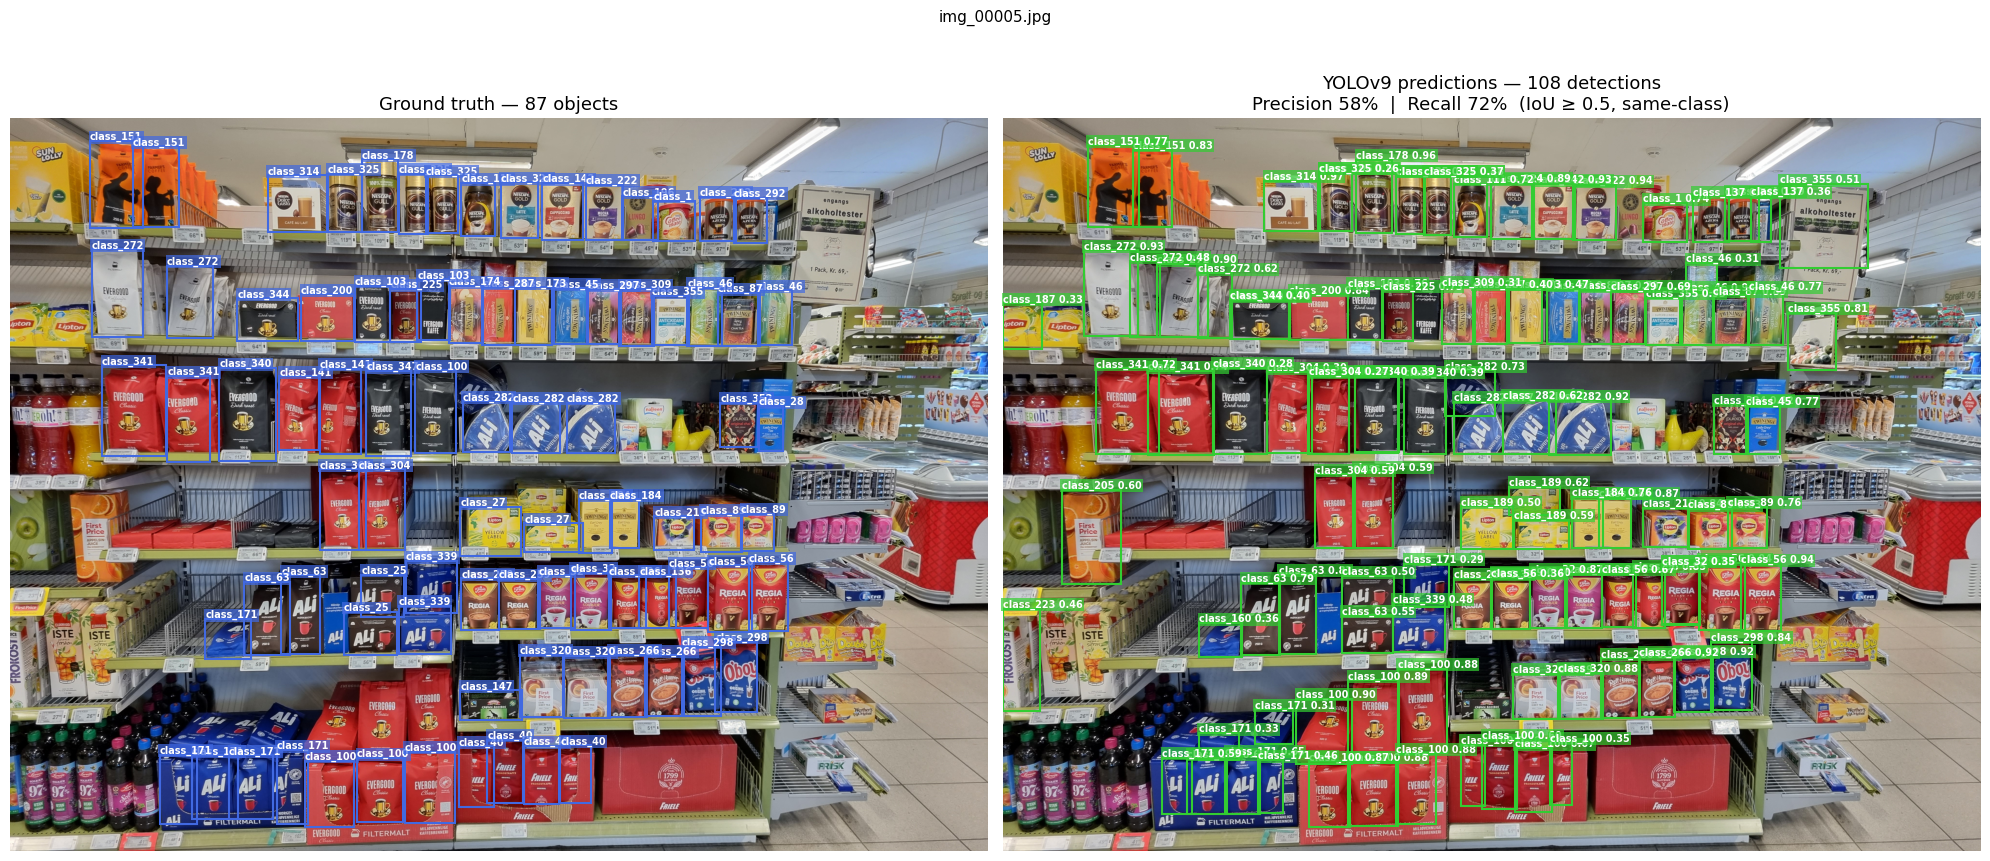

GT: 87 | Pred: 108 | Matched: 63
Precision: 58.3%   Recall: 72.4%
Saved → results/yolov9_demo_inference.png


In [ ]:
def draw_boxes(ax, boxes_xyxy, labels, color, fontsize=7):
    for (x1, y1, x2, y2), lbl in zip(boxes_xyxy, labels):
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=1.5, edgecolor=color, facecolor="none"
        ))
        ax.text(
            x1, y1 - 4, lbl,
            color="white", fontsize=fontsize, fontweight="bold",
            bbox=dict(facecolor=color, alpha=0.7, pad=1, edgecolor="none")
        )

img = Image.open(img_path).convert("RGB")
W, H = img.size

label_path = Path(str(img_path).replace("/images/", "/labels/")).with_suffix(".txt")
gt_boxes, gt_labels = [], []
for line in label_path.read_text().strip().splitlines():
    cls_id, cx, cy, bw, bh = map(float, line.split())
    x1 = (cx - bw / 2) * W
    y1 = (cy - bh / 2) * H
    x2 = (cx + bw / 2) * W
    y2 = (cy + bh / 2) * H
    gt_boxes.append((x1, y1, x2, y2))
    gt_labels.append(model.names[int(cls_id)])

pred_boxes, pred_labels = [], []
for box in results.boxes:
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    conf = float(box.conf[0])
    cls_id = int(box.cls[0])
    pred_boxes.append((x1, y1, x2, y2))
    pred_labels.append(f"{model.names[cls_id]} {conf:.2f}")

def iou(b1, b2):
    ix1, iy1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    ix2, iy2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    a1 = (b1[2] - b1[0]) * (b1[3] - b1[1])
    a2 = (b2[2] - b2[0]) * (b2[3] - b2[1])
    return inter / (a1 + a2 - inter + 1e-6)

matched = sum(
    any(iou(pb, gb) > 0.5 and pl.rsplit(" ", 1)[0] == gl
        for gb, gl in zip(gt_boxes, gt_labels))
    for pb, pl in zip(pred_boxes, pred_labels)
)
precision = matched / len(pred_boxes) if pred_boxes else 0
recall    = matched / len(gt_boxes)   if gt_boxes   else 0

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

axes[0].imshow(img)
draw_boxes(axes[0], gt_boxes, gt_labels, color="royalblue")
axes[0].set_title(f"Ground truth — {len(gt_boxes)} objects", fontsize=13)
axes[0].axis("off")

axes[1].imshow(img)
draw_boxes(axes[1], pred_boxes, pred_labels, color="limegreen")
axes[1].set_title(
    f"YOLOv9 predictions — {len(pred_boxes)} detections\n"
    f"Precision {precision:.0%}  |  Recall {recall:.0%}  (IoU ≥ 0.5, same-class)",
    fontsize=13
)
axes[1].axis("off")

plt.suptitle(img_path.name, fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("../results/yolov9_demo_inference.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"GT: {len(gt_boxes)} | Pred: {len(pred_boxes)} | Matched: {matched}")
print(f"Precision: {precision:.1%}   Recall: {recall:.1%}")
print("Saved → results/yolov9_demo_inference.png")